# **PREPROCESSING AND ETHICAL EVALUATION OF HEALTH DATA FOR HEART DISEASE CLASSIFICATION IN MACHINE LEARNING**



The **objective** of this project is to investigate and prepare a dataset of cardiovascular diseases for future use in a machine learning classification task that predicts the presence of heart disease. This includes exploring aspects such as Data Cleaning, Exploratory Data Analysis, Data Integration, Data Reduction, and Data Transformationdata while considering the ethical issues associated with the processing of sensitive health data.



## **Steps to Use the Dataset**


### **1. Loading and Previewing Dataset**


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart_2020_raw.csv")
print(df.shape)  # Should show > 10 variables and > 5,000 records
df.head()

(445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


### **2. Creating a target variable and selecting 14 features** (based on medical relevance)

In [21]:
# Defining the selected 14 columns
selected_columns = ['HadHeartAttack', 
    'HadAngina',
    'HadStroke', 
    'AgeCategory', 
    'Sex', 
    'RaceEthnicityCategory',
    'BMI', 
    'SmokerStatus',
    'AlcoholDrinkers',
    'PhysicalActivities', 
    'SleepHours', 
    'HadDiabetes', 
    'HadKidneyDisease',
    'HadArthritis',
    'MentalHealthDays',
    'CovidPos']

# Creating a target variable 'HeartDisease' from heart attack, angina, or stroke
df['HeartDisease'] = df[['HadHeartAttack', 'HadAngina', 'HadStroke']].apply(lambda x: 1 if 'Yes' in x.values else 0, axis=1)

# Dropping the 3 individual condition columns
final_columns = ['HeartDisease'] + [col for col in selected_columns if col not in ['HadHeartAttack', 'HadAngina', 'HadStroke']]

# Extracting and saving the cleaned subset
heart_subset = df[final_columns]


In [22]:
print(heart_subset['HeartDisease'].value_counts(normalize=True))

HeartDisease
0    0.882606
1    0.117394
Name: proportion, dtype: float64


### Final Feature Table: 14 Columns for Heart Disease Study

| No. | Column Name             | Description |
|-----|-------------------------|-------------|
| 1   | **HeartDisease** *(derived)* | Binary target variable: 1 if respondent reported **heart attack**, **angina**, or **stroke**; derived from `HadHeartAttack`, `HadAngina`, and `HadStroke`. |
| 2   | **AgeCategory**         | Categorical variable indicating respondent's **age group** (e.g., '35–39', '70–74'); useful for assessing **age-related cardiovascular risk**. |
| 3   | **Sex**                 | Sex of the respondent; enables analysis of **sex-based risk differences** in heart disease. |
| 4   | **RaceEthnicityCategory** | Self-reported **race/ethnicity** category; helps identify **health disparities** and supports **fairness analysis**. |
| 5   | **BMI**                 | **Body Mass Index**, scaled to float (kg/m²); a standard measure of obesity, a major heart disease risk factor. |
| 6   | **SmokerStatus**        | Categorical status of smoking behavior (e.g., current, former, never); a **primary lifestyle risk factor**. |
| 7   | **AlcoholDrinkers**     | Indicates if respondent had **any alcoholic drinks in the past 30 days**; excessive alcohol use impacts cardiovascular health. |
| 8   | **PhysicalActivities**  | Binary indicator of whether the respondent did **any physical activity outside of work** in the past month; relevant for **preventive health behaviors**. |
| 9   | **SleepHours**          | Average **number of sleep hours per day**; short or excessive sleep has been linked to **cardiovascular issues**. |
| 10  | **HadDiabetes**         | Binary indicator for whether the respondent was told they had **diabetes**; an important **comorbidity**. |
| 11  | **HadKidneyDisease**    | Whether respondent was diagnosed with **chronic kidney disease** (excluding temporary infections); affects heart risk. |
| 12  | **HadArthritis**        | Indicates **arthritis diagnosis**; may suggest **chronic inflammation** and **reduced physical activity**, both relevant to heart health. |
| 13  | **MentalHealthDays**    | Number of days in the past 30 when **mental health was "not good"**; high values can indicate **psychological stress**, which affects the heart. |
| 14  | **CovidPos**            | Binary variable indicating if the respondent was **diagnosed with COVID-19**; relevant due to emerging links between COVID-19 and **cardiovascular complications**. |



## **Steps in Exploratory Data Analysis (EDA)**


### **1. Dataset Overview**

In [23]:
heart_subset.info()         # Understanding types, null counts for each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   HeartDisease           445132 non-null  int64  
 1   AgeCategory            436053 non-null  object 
 2   Sex                    445132 non-null  object 
 3   RaceEthnicityCategory  431075 non-null  object 
 4   BMI                    396326 non-null  float64
 5   SmokerStatus           409670 non-null  object 
 6   AlcoholDrinkers        398558 non-null  object 
 7   PhysicalActivities     444039 non-null  object 
 8   SleepHours             439679 non-null  float64
 9   HadDiabetes            444045 non-null  object 
 10  HadKidneyDisease       443206 non-null  object 
 11  HadArthritis           442499 non-null  object 
 12  MentalHealthDays       436065 non-null  float64
 13  CovidPos               394368 non-null  object 
dtypes: float64(3), int64(1), object(10)


In [24]:
heart_subset.iloc[:4, 0:14]     # Preview data values ​​in selected rows/columns

,HeartDisease,AgeCategory,Sex,RaceEthnicityCategory,BMI,SmokerStatus,AlcoholDrinkers,PhysicalActivities,SleepHours,HadDiabetes,HadKidneyDisease,HadArthritis,MentalHealthDays,CovidPos
0,0,Age 80 or older,Female,"White only, Non-Hispanic",NaN,Never smoked,No,No,8.0,Yes,No,No,0.0,No
1,0,Age 80 or older,Female,"White only, Non-Hispanic",26.57,Never smoked,No,No,6.0,No,No,No,0.0,No
2,0,Age 55 to 59,Female,"White only, Non-Hispanic",25.61,Never smoked,No,Yes,5.0,No,No,No,3.0,Yes
3,0,NaN,Female,"White only, Non-Hispanic",23.30,Current smoker - now smokes some days,No,Yes,7.0,No,No,Yes,0.0,No


### 2. **Summary Statistics**

In [25]:
heart_subset.describe(include='all')

,HeartDisease,AgeCategory,Sex,RaceEthnicityCategory,BMI,SmokerStatus,AlcoholDrinkers,PhysicalActivities,SleepHours,HadDiabetes,HadKidneyDisease,HadArthritis,MentalHealthDays,CovidPos
count,445132.000000,436053,445132,431075,396326.000000,409670,398558,444039,439679.000000,444045,443206,442499,436065.000000,394368
unique,NaN,13,2,5,NaN,4,2,2,NaN,4,2,2,NaN,3
top,NaN,Age 65 to 69,Female,"White only, Non-Hispanic",NaN,Never smoked,Yes,Yes,NaN,No,No,No,NaN,No
freq,NaN,47099,235893,320421,NaN,245955,210891,337559,NaN,368722,422891,291351,NaN,270055
mean,0.117394,NaN,NaN,NaN,28.529842,NaN,NaN,NaN,7.022983,NaN,NaN,NaN,4.382649,NaN
std,0.321890,NaN,NaN,NaN,6.554889,NaN,NaN,NaN,1.502425,NaN,NaN,NaN,8.387475,NaN
min,0.000000,NaN,NaN,NaN,12.020000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN
25%,0.000000,NaN,NaN,NaN,24.130000,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,0.000000,NaN
50%,0.000000,NaN,NaN,NaN,27.440000,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,0.000000,NaN
75%,0.000000,NaN,NaN,NaN,31.750000,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,5.000000,NaN


### **3. Missing Value Analysis**

### Summary of missing values

In [26]:
# Count and percentage of missing values
missing_counts = heart_subset.isnull().sum()
missing_percent = (missing_counts / len(heart_subset)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_counts,
    'Missing %': missing_percent.round(2)}).sort_values(by='Missing %', ascending=False)

missing_df

,Missing Count,Missing %
CovidPos,50764,11.40
BMI,48806,10.96
AlcoholDrinkers,46574,10.46
SmokerStatus,35462,7.97
RaceEthnicityCategory,14057,3.16
AgeCategory,9079,2.04
MentalHealthDays,9067,2.04
SleepHours,5453,1.23
HadArthritis,2633,0.59
HadKidneyDisease,1926,0.43


### Bar Plot of Missing Data

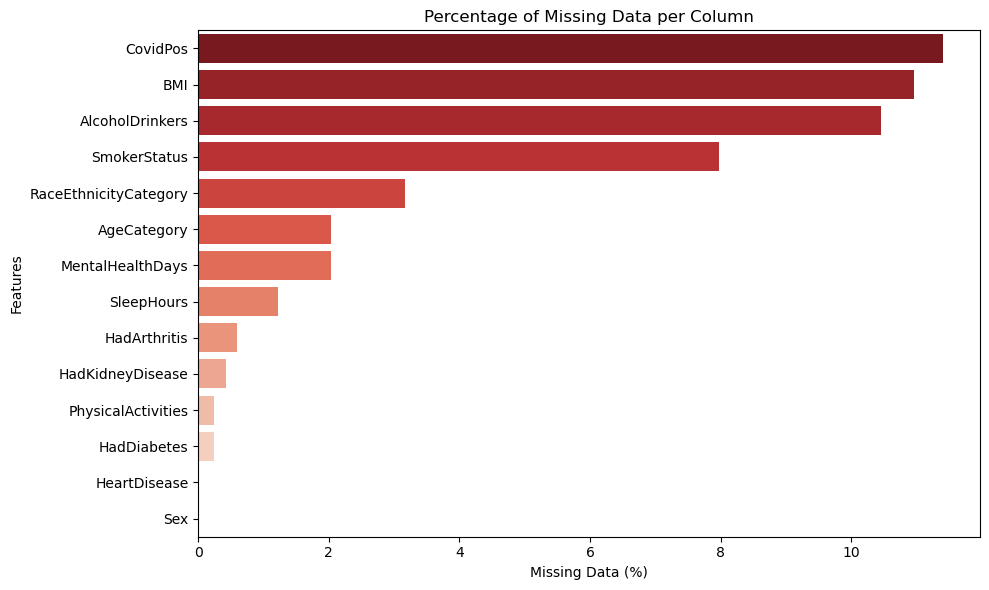

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(y=missing_df.index, x=missing_df['Missing %'], hue=missing_df.index, palette='Reds_r', dodge=False, legend=False)
plt.title('Percentage of Missing Data per Column')
plt.xlabel('Missing Data (%)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

###  Heatmap of Missing Data
This visual is helpful to **quickly identify patterns of missingness**, for example, whether missing data is random or concentrated in particular rows (which may suggest data collection issues).

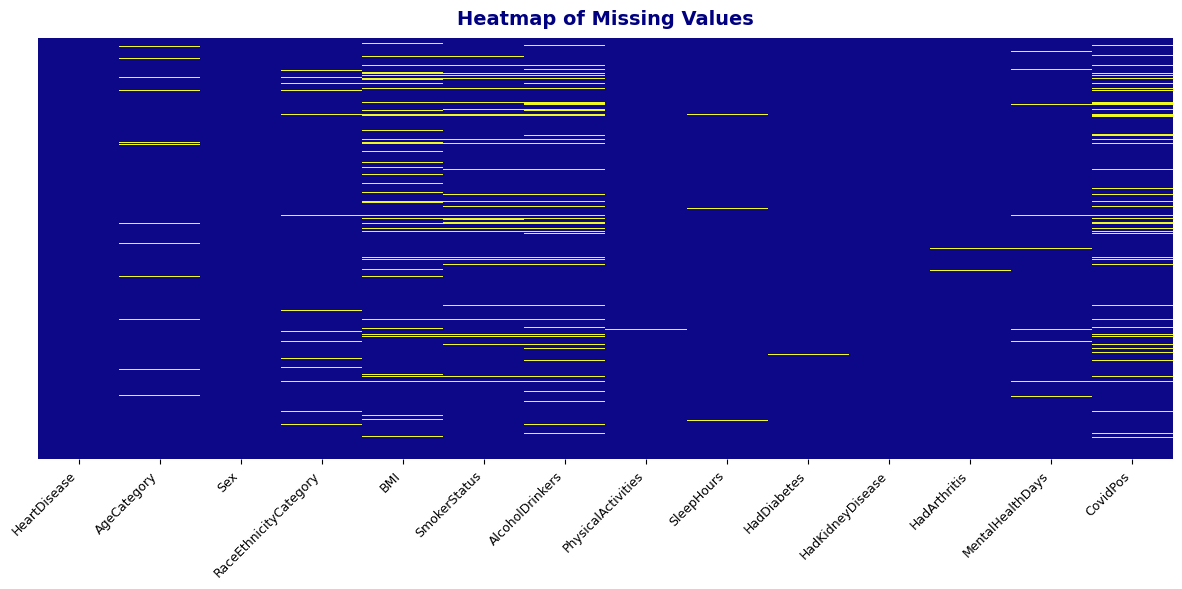

In [28]:
plt.figure(figsize=(12, 6))
sns.heatmap(heart_subset.isnull(), cbar=False, yticklabels=False, cmap='plasma')
plt.title('Heatmap of Missing Values', fontsize=14, color='navy', pad=10, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### Vertical Clustering (Columns)
Columns like *CovidPos*, *BMI*, *SmokerStatus*, *AlcoholDrinkers* show many missing entries, forming vertical yellow streaks in the missing data heatmap.

**Interpretation:**  
These variables may have had voluntary response options (e.g., participants might skip COVID-related or weight questions).  
Data collection instruments may not have required these fields for all participants.

### Horizontal Clustering (Rows)
Some rows have multiple missing features, seen as horizontal bands of missing data.

**Interpretation:**  
These may be records from respondents who dropped out early or skipped large sections of the survey.  
Could indicate systematic non-response from certain groups (e.g., elderly respondents or specific age groups).
age group).

### Correlation of Missingness Between Features

**Correlation matrix of missingness** are **valid without encoding**, because they are based on **Boolean masks** (i.e., *.isnull()*), not on the data values themselves.

In [29]:
heart_subset.isnull().corr()

,HeartDisease,AgeCategory,Sex,RaceEthnicityCategory,BMI,SmokerStatus,AlcoholDrinkers,PhysicalActivities,SleepHours,HadDiabetes,HadKidneyDisease,HadArthritis,MentalHealthDays,CovidPos
HeartDisease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,NaN,1.000000,NaN,0.165068,0.175011,0.082156,0.085369,0.034267,0.045914,0.065635,0.047633,0.045245,0.031060,0.077381
Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RaceEthnicityCategory,NaN,0.165068,NaN,1.000000,0.092375,0.056700,0.060238,0.034907,0.042018,0.055875,0.044072,0.042694,0.038165,0.055041
BMI,NaN,0.175011,NaN,0.092375,1.000000,0.449286,0.407562,0.027772,0.048704,0.038724,0.027148,0.025252,0.037608,0.382079
SmokerStatus,NaN,0.082156,NaN,0.056700,0.449286,1.000000,0.787540,0.026977,0.027347,0.031502,0.025099,0.021340,0.025236,0.745134
AlcoholDrinkers,NaN,0.085369,NaN,0.060238,0.407562,0.787540,1.000000,0.024713,0.034527,0.030228,0.022307,0.018714,0.032595,0.837246
PhysicalActivities,NaN,0.034267,NaN,0.034907,0.027772,0.026977,0.024713,1.000000,0.055960,0.085835,0.072802,0.070759,0.051972,0.020186
SleepHours,NaN,0.045914,NaN,0.042018,0.048704,0.027347,0.034527,0.055960,1.000000,0.044972,0.052089,0.042811,0.093530,0.023524
HadDiabetes,NaN,0.065635,NaN,0.055875,0.038724,0.031502,0.030228,0.085835,0.044972,1.000000,0.220730,0.204530,0.032821,0.027356


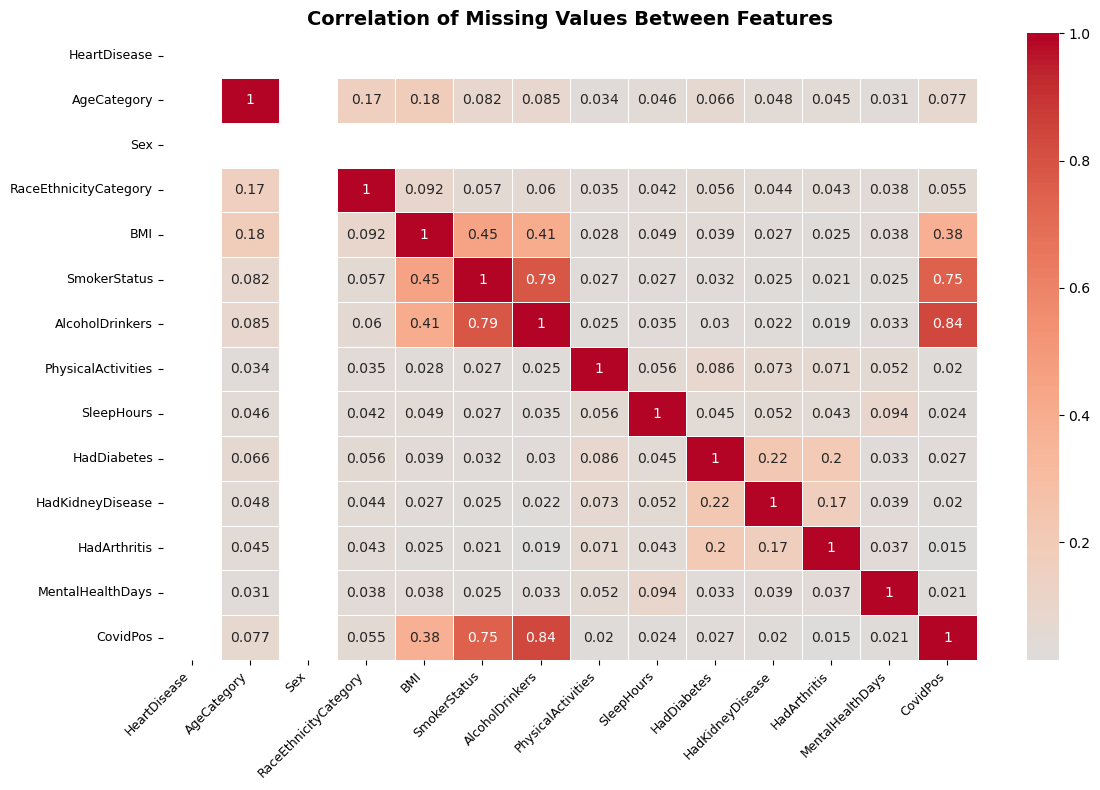

In [30]:
# Create a correlation matrix for missing values
missing_corr = heart_subset.isnull().corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, linecolor='white')

plt.title('Correlation of Missing Values Between Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### **4. Univariate Analysis (Column-wise)**

In [31]:
heart_subset['AgeCategory'].value_counts(dropna=False)

AgeCategory
Age 65 to 69       47099
Age 60 to 64       44511
Age 70 to 74       43472
Age 55 to 59       36821
Age 80 or older    36251
Age 50 to 54       33644
Age 75 to 79       32518
Age 40 to 44       29942
Age 45 to 49       28531
Age 35 to 39       28526
Age 18 to 24       26941
Age 30 to 34       25807
Age 25 to 29       21990
NaN                 9079
Name: count, dtype: int64

In [32]:
heart_subset['CovidPos'].value_counts(dropna=False)

CovidPos
No                                                               270055
Yes                                                              110877
NaN                                                               50764
Tested positive using home test without a health professional     13436
Name: count, dtype: int64

In [33]:
heart_subset['SmokerStatus'].value_counts(dropna=False)

SmokerStatus
Never smoked                             245955
Former smoker                            113774
Current smoker - now smokes every day     36003
NaN                                       35462
Current smoker - now smokes some days     13938
Name: count, dtype: int64

In [34]:
heart_subset['HadDiabetes'].value_counts(dropna=False)

HadDiabetes
No                                         368722
Yes                                         61158
No, pre-diabetes or borderline diabetes     10329
Yes, but only during pregnancy (female)      3836
NaN                                          1087
Name: count, dtype: int64

 ### **5. MCAR/MAR/MNAR inspection**

| Type | Full Name                    | Description                                                                                         |
|------|------------------------------|-----------------------------------------------------------------------------------------------------|
| MCAR | Missing Completely at Random | Missing values have no relation to any variable in the dataset (missingness is purely random).      |
| MAR  | Missing at Random            | Missingness is related to other observed variables but not the missing variable itself.             |
| MNAR | Missing Not at Random        | Missingness is related to the unobserved value itself (very hard to detect with standard analysis). |


The heatmap visually inspects the structure of missingness:
- The missing values in columns like *AgeCategory* and *CovidPos* appear partially structured, which does not strongly support **MCAR**.
- Clustered or patterned missingness may indicate **MAR** or even **MNAR**.

### (1) Identify columns with Missing Data

In [35]:
missing_cols = heart_subset.columns[heart_subset.isnull().any()]
print("Columns with missing values:", missing_cols.tolist())

Columns with missing values: ['AgeCategory', 'RaceEthnicityCategory', 'BMI', 'SmokerStatus', 'AlcoholDrinkers', 'PhysicalActivities', 'SleepHours', 'HadDiabetes', 'HadKidneyDisease', 'HadArthritis', 'MentalHealthDays', 'CovidPos']


### (2) Create Missingness Indicator Columns

Statistical and visual tests can't operate on "missingness" directly, so we turn it into a binary variable:

- `1` = value is missing  
- `0` = value is present  

These flags let us compare missing vs non-missing groups.


In [36]:
heart_subset = heart_subset.copy() 

for col in missing_cols:
    heart_subset.loc[:, f'miss_{col}'] = heart_subset[col].isnull().astype(int)

### (3A) Visual MAR Check - Categorical Features
Counts plots to see if missingness relates to class labels

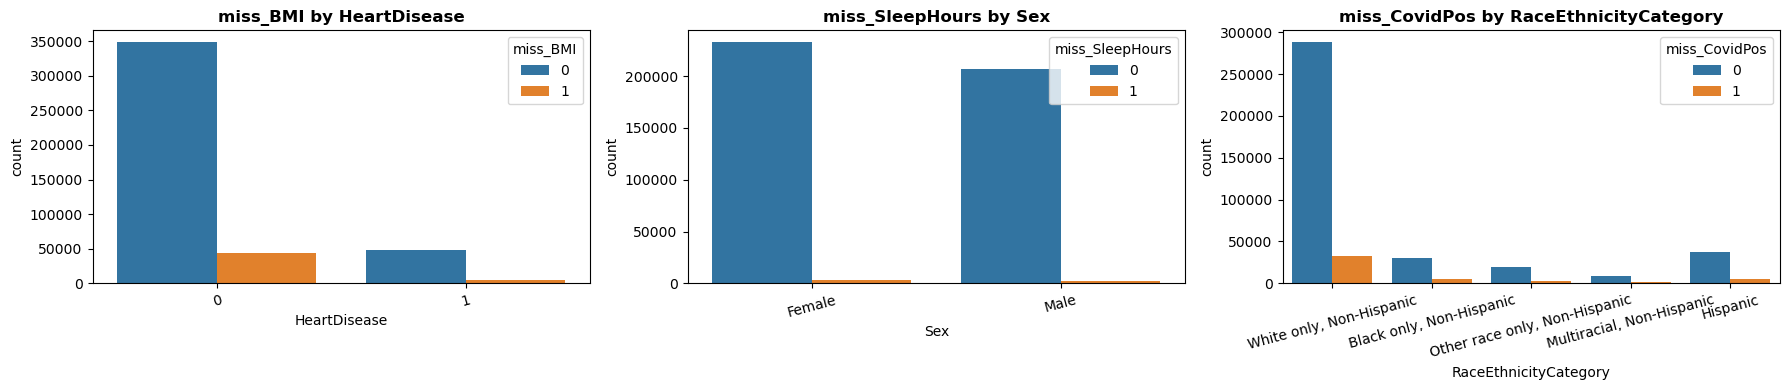

In [37]:
# Example Categorical variables and missingness columns
categorical_test_vars = ['HeartDisease', 'Sex', 'RaceEthnicityCategory']
example_miss_cols = ['miss_BMI', 'miss_SleepHours', 'miss_CovidPos']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, (cat, miss_col) in enumerate(zip(categorical_test_vars, example_miss_cols)):
    if miss_col in heart_subset.columns and cat in heart_subset.columns:
        sns.countplot(data=heart_subset, x=cat, hue=miss_col, ax=axes[i])
        axes[i].set_title(f"{miss_col} by {cat}", fontweight='bold')
        axes[i].tick_params(axis='x', rotation=15)  
plt.tight_layout()
plt.show()

### (3B) Visual MAR Check — Numeric Features
Boxplots to see if numeric values differ between missing vs non-missing groups

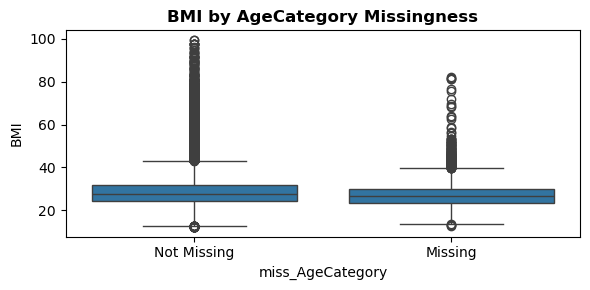

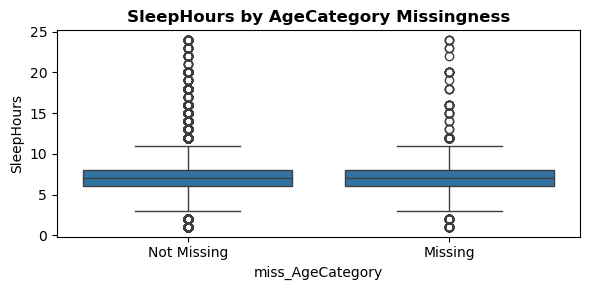

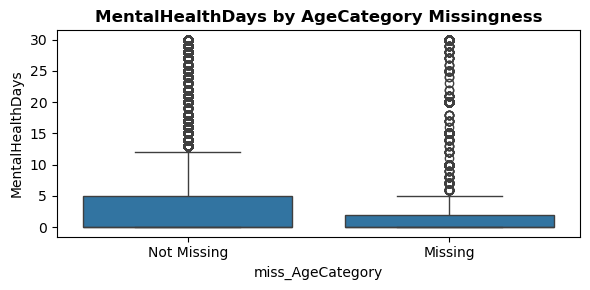

In [38]:
# Numeric features to test against
numerical_test_vars = ['BMI', 'SleepHours', 'MentalHealthDays']
missing_cols = ['AgeCategory']

# Boxplot
for miss_col in missing_cols:
    miss_flag = f'miss_{miss_col}'
    
    # Creating the missingness flag if it doesn't exist
    if miss_flag not in heart_subset.columns:
        heart_subset[miss_flag] = heart_subset[miss_col].isnull().astype(int)

    for num in numerical_test_vars:
        if miss_col != num:
            plt.figure(figsize=(6, 3))
            sns.boxplot(data=heart_subset, x=miss_flag, y=num)
            plt.title(f"{num} by {miss_col} Missingness", fontweight='bold')
            plt.xticks([0, 1], ['Not Missing', 'Missing'])
            plt.tight_layout()
            plt.show()


### (4) Statistical Tests for MAR (Chi-square and t-test)

Chi-square test: is missingness in a column related to a categorical feature?

In [39]:
from scipy.stats import chi2_contingency

for miss_col in missing_cols:
    for cat in categorical_test_vars:
        contingency = pd.crosstab(heart_subset[cat], heart_subset[f'miss_{miss_col}'])
        if contingency.shape[1] == 2:
            chi2, p, _, _ = chi2_contingency(contingency)
            print(f"Chi-square test: Missing {miss_col} vs {cat} → p = {p:.4f}")

Chi-square test: Missing AgeCategory vs HeartDisease → p = 0.0000
Chi-square test: Missing AgeCategory vs Sex → p = 0.0003
Chi-square test: Missing AgeCategory vs RaceEthnicityCategory → p = 0.0000


T-test: is the distribution of a numeric feature different between missing/not-missing?

In [40]:
from scipy.stats import ttest_ind

for miss_col in missing_cols:
    for num in numerical_test_vars:
        group0 = heart_subset[heart_subset[f'miss_{miss_col}'] == 0][num].dropna()
        group1 = heart_subset[heart_subset[f'miss_{miss_col}'] == 1][num].dropna()
        if not group0.empty and not group1.empty:
            t_stat, p = ttest_ind(group0, group1, equal_var=False)
            print(f"T-test: {num} vs Missing {miss_col} → p = {p:.4f}")

T-test: BMI vs Missing AgeCategory → p = 0.0000
T-test: SleepHours vs Missing AgeCategory → p = 0.1649
T-test: MentalHealthDays vs Missing AgeCategory → p = 0.0000


### Interpretation of Results

| Evidence                               | Interpretation                                                   |
|-------------------------------------------|------------------------------------------------------------------|
| *p* < 0.05 in t-test or chi-square         | Strong indication of MAR (missingness depends on observed variable) |
| Plots show large differences               | Visual sign of MAR                                               |
| No pattern, *p* ≥ 0.05                     | Could be MCAR (missingness is random)                            |


## **Steps for Handle Missing Values (Post-EDA)**

### (1) *AgeCategory*
Categorical, MAR (related to *Sex* and *Race*), group-wise mode imputation

In [41]:
heart_subset['AgeCategory'] = heart_subset.groupby(['Sex', 'RaceEthnicityCategory'])['AgeCategory'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Age 55 to 59'))

# Final fallback if anything remains
heart_subset['AgeCategory'] = heart_subset['AgeCategory'].fillna('Age 55 to 59')

### (2) *RaceEthnicityCategory*
Categorical, MAR (related to *Sex*), group-wise mode imputation

In [42]:
heart_subset['RaceEthnicityCategory'] = heart_subset.groupby('Sex')['RaceEthnicityCategory'].transform(lambda x: x.fillna(x.mode()[0]))


### (3) *BMI*
Numeric, MAR (related to *MentalHealthDays* and *SleepHours*), KNN Imputer

In [43]:
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=5)
heart_subset[['BMI', 'SleepHours', 'MentalHealthDays']] = knn.fit_transform(heart_subset[['BMI', 'SleepHours', 'MentalHealthDays']])

### (4) *SmokerStatus*
Categorical, MAR (related to *Sex* and *Race*), group-wise mode

In [44]:
heart_subset['SmokerStatus'] = heart_subset.groupby(['Sex', 'RaceEthnicityCategory'])['SmokerStatus'].transform(lambda x: x.fillna(x.mode()[0]))


### (5) *AlcoholDrinkers*
Categorical, MAR, group-wise mode

In [45]:
heart_subset['AlcoholDrinkers'] = heart_subset.groupby(['Sex', 'RaceEthnicityCategory'])['AlcoholDrinkers'].transform(lambda x: x.fillna(x.mode()[0]))


### (6) *PhysicalActivities*
Categorical (Yes/No), Possibly MCAR, simple mode imputation

In [46]:
heart_subset['PhysicalActivities'] = heart_subset['PhysicalActivities'].fillna(heart_subset['PhysicalActivities'].mode()[0])


### (7) *SleepHours*
Numeric, Weak MAR, group-wise mean

In [47]:
heart_subset['SleepHours'] = heart_subset.groupby(['Sex', 'AgeCategory'])['SleepHours'].transform(
    lambda x: x.fillna(x.mean() if not x.dropna().empty else heart_subset['SleepHours'].mean()))

# Final fallback (if any still remain)
heart_subset['SleepHours'] = heart_subset['SleepHours'].fillna(heart_subset['SleepHours'].mean())

### (8–10) *HadDiabetes*, *HadKidneyDisease*, *HadArthritis*
Categorical (Yes/No), weak MAR or MCAR, simple mode imputation

In [48]:
for col in ['HadDiabetes', 'HadKidneyDisease', 'HadArthritis']:
    heart_subset[col] = heart_subset[col].fillna(heart_subset[col].mode()[0])


### (11) *MentalHealthDays*
Numeric, MAR, group-wise median

In [49]:
heart_subset['MentalHealthDays'] = heart_subset.groupby(['Sex', 'RaceEthnicityCategory'])['MentalHealthDays'].transform(lambda x: x.fillna(x.median()))


### (12) *CovidPos*
Categorical, MAR or MNAR (sensitive variable), impute as 'No', but keep missing flag

In [50]:
# Create missing flag
heart_subset['CovidPos_missing'] = heart_subset['CovidPos'].isnull().astype(int)

# Safely fill missing values
heart_subset['CovidPos'] = heart_subset['CovidPos'].fillna('No')


### Final Check

In [51]:
# Confirm no missing values
print(heart_subset.isnull().sum().sort_values(ascending=False))


HeartDisease                  0
miss_AgeCategory              0
miss_CovidPos                 0
miss_MentalHealthDays         0
miss_HadArthritis             0
miss_HadKidneyDisease         0
miss_HadDiabetes              0
miss_SleepHours               0
miss_PhysicalActivities       0
miss_AlcoholDrinkers          0
miss_SmokerStatus             0
miss_BMI                      0
miss_RaceEthnicityCategory    0
CovidPos                      0
AgeCategory                   0
MentalHealthDays              0
HadArthritis                  0
HadKidneyDisease              0
HadDiabetes                   0
SleepHours                    0
PhysicalActivities            0
AlcoholDrinkers               0
SmokerStatus                  0
BMI                           0
RaceEthnicityCategory         0
Sex                           0
CovidPos_missing              0
dtype: int64


### Deleting temporary miss_columns

In [52]:
heart_subset = heart_subset.drop(columns=[col for col in heart_subset.columns if col.startswith('miss_') or col == 'CovidPos_missing'])
heart_subset.shape

(445132, 14)

## Duplicates & Outliers

In [53]:
print("Before cleaning:")
print("Shape:", heart_subset.shape)
print("Duplicates:", heart_subset.duplicated().sum())
print(" ")

# Removing duplicates
heart_subset = heart_subset.drop_duplicates().reset_index(drop=True)

# Removing outliers (IQR method)
numeric_cols = ['BMI', 'SleepHours', 'MentalHealthDays']
for col in numeric_cols:
    Q1 = heart_subset[col].quantile(0.25)
    Q3 = heart_subset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(heart_subset)
    heart_subset = heart_subset[(heart_subset[col] >= lower) & (heart_subset[col] <= upper)]
    after = len(heart_subset)
    print(f"{col}: Removed {before - after} outliers")

print(" ")
print("After cleaning:")
print("Shape:", heart_subset.shape)
print("Duplicates:", heart_subset.duplicated().sum())

Before cleaning:
Shape: (445132, 14)
Duplicates: 49622
 
BMI: Removed 12934 outliers
SleepHours: Removed 6840 outliers
MentalHealthDays: Removed 54384 outliers
 
After cleaning:
Shape: (321352, 14)
Duplicates: 0


## Saving to CSV (subset of 14 columns)

In [54]:
heart_subset.to_csv('heart_subset_cleaned.csv', index=False)
print("Saved: heart_subset_cleaned.csv")

Saved: heart_subset_cleaned.csv


## **Steps for Analysing and Preprocessing a Dataset** (continued)

In [55]:
import pandas as pd
heart_cleaned = pd.read_csv("heart_subset_cleaned.csv")
heart_cleaned.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321352 entries, 0 to 321351
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   HeartDisease           321352 non-null  int64  
 1   AgeCategory            321352 non-null  object 
 2   Sex                    321352 non-null  object 
 3   RaceEthnicityCategory  321352 non-null  object 
 4   BMI                    321352 non-null  float64
 5   SmokerStatus           321352 non-null  object 
 6   AlcoholDrinkers        321352 non-null  object 
 7   PhysicalActivities     321352 non-null  object 
 8   SleepHours             321352 non-null  float64
 9   HadDiabetes            321352 non-null  object 
 10  HadKidneyDisease       321352 non-null  object 
 11  HadArthritis           321352 non-null  object 
 12  MentalHealthDays       321352 non-null  float64
 13  CovidPos               321352 non-null  object 
dtypes: float64(3), int64(1), object(10)


### Exploring Unique Values

In [56]:
for col in heart_cleaned.select_dtypes(include='object').columns:
    print(f"\n{col} unique values:")
    print(heart_cleaned[col].unique())


AgeCategory unique values:
['Age 80 or older' 'Age 55 to 59' 'Age 65 to 69' 'Age 40 to 44'
 'Age 75 to 79' 'Age 70 to 74' 'Age 60 to 64' 'Age 50 to 54'
 'Age 45 to 49' 'Age 35 to 39' 'Age 30 to 34' 'Age 25 to 29'
 'Age 18 to 24']

Sex unique values:
['Female' 'Male']

RaceEthnicityCategory unique values:
['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' 'Hispanic']

SmokerStatus unique values:
['Never smoked' 'Current smoker - now smokes some days' 'Former smoker'
 'Current smoker - now smokes every day']

AlcoholDrinkers unique values:
['No' 'Yes']

PhysicalActivities unique values:
['No' 'Yes']

HadDiabetes unique values:
['Yes' 'No' 'No, pre-diabetes or borderline diabetes'
 'Yes, but only during pregnancy (female)']

HadKidneyDisease unique values:
['No' 'Yes']

HadArthritis unique values:
['No' 'Yes']

CovidPos unique values:
['No' 'Yes'
 'Tested positive using home test without a health professional']


### Code to Fix Data Types

In [57]:
categorical_cols = ['AgeCategory', 'Sex', 'RaceEthnicityCategory', 'SmokerStatus', 'AlcoholDrinkers',
                    'PhysicalActivities', 'HadDiabetes', 'HadKidneyDisease', 'HadArthritis', 'CovidPos']

for col in categorical_cols:
    heart_cleaned[col] = heart_cleaned[col].astype('category')

heart_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321352 entries, 0 to 321351
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   HeartDisease           321352 non-null  int64   
 1   AgeCategory            321352 non-null  category
 2   Sex                    321352 non-null  category
 3   RaceEthnicityCategory  321352 non-null  category
 4   BMI                    321352 non-null  float64 
 5   SmokerStatus           321352 non-null  category
 6   AlcoholDrinkers        321352 non-null  category
 7   PhysicalActivities     321352 non-null  category
 8   SleepHours             321352 non-null  float64 
 9   HadDiabetes            321352 non-null  category
 10  HadKidneyDisease       321352 non-null  category
 11  HadArthritis           321352 non-null  category
 12  MentalHealthDays       321352 non-null  float64 
 13  CovidPos               321352 non-null  category
dtypes: category(10), flo

### **(1) Encode Categorical Data**

| Version                | Use For                           | 
|------------------------|-----------------------------------|
| `heart_label_encoded`  | RandomForest, XGBoost, LightGBM   | 
| `heart_onehot_encoded` | Logistic Regression, SVM, k-NN    |


**Label Encoding** 

In [58]:
from sklearn.preprocessing import LabelEncoder

# Creating a copy to keep label-encoded version
heart_label_encoded = heart_cleaned.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    heart_label_encoded[col] = le.fit_transform(heart_label_encoded[col])
    label_encoders[col] = le  # store encoders for inverse_transform or future use

heart_label_encoded[categorical_cols].head()

,AgeCategory,Sex,RaceEthnicityCategory,SmokerStatus,AlcoholDrinkers,PhysicalActivities,HadDiabetes,HadKidneyDisease,HadArthritis,CovidPos
0,12,0,4,3,0,0,2,0,0,0
1,12,0,4,3,0,0,0,0,0,0
2,7,0,4,3,0,1,0,0,0,2
3,9,0,4,1,0,1,0,0,1,0
4,4,0,4,3,1,1,0,0,0,0


**One-Hot Encoding**

In [59]:
# One-hot encode categorical variables and drop the first category to avoid multicollinearity
heart_onehot_encoded = pd.get_dummies(heart_cleaned, columns=categorical_cols, drop_first=True)

heart_onehot_encoded.head()

,HeartDisease,BMI,SleepHours,MentalHealthDays,AgeCategory_Age 25 to 29,AgeCategory_Age 30 to 34,AgeCategory_Age 35 to 39,AgeCategory_Age 40 to 44,AgeCategory_Age 45 to 49,AgeCategory_Age 50 to 54,...,SmokerStatus_Never smoked,AlcoholDrinkers_Yes,PhysicalActivities_Yes,"HadDiabetes_No, pre-diabetes or borderline diabetes",HadDiabetes_Yes,"HadDiabetes_Yes, but only during pregnancy (female)",HadKidneyDisease_Yes,HadArthritis_Yes,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
0,0,27.28,8.0,0.0,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
1,0,26.57,6.0,0.0,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,0,25.61,5.0,3.0,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
3,0,23.30,7.0,0.0,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,0,21.77,9.0,0.0,False,False,False,True,False,False,...,True,True,True,False,False,False,False,False,False,False


### **(2) Feature Scaling**

**Quick Test on Log Normalization**

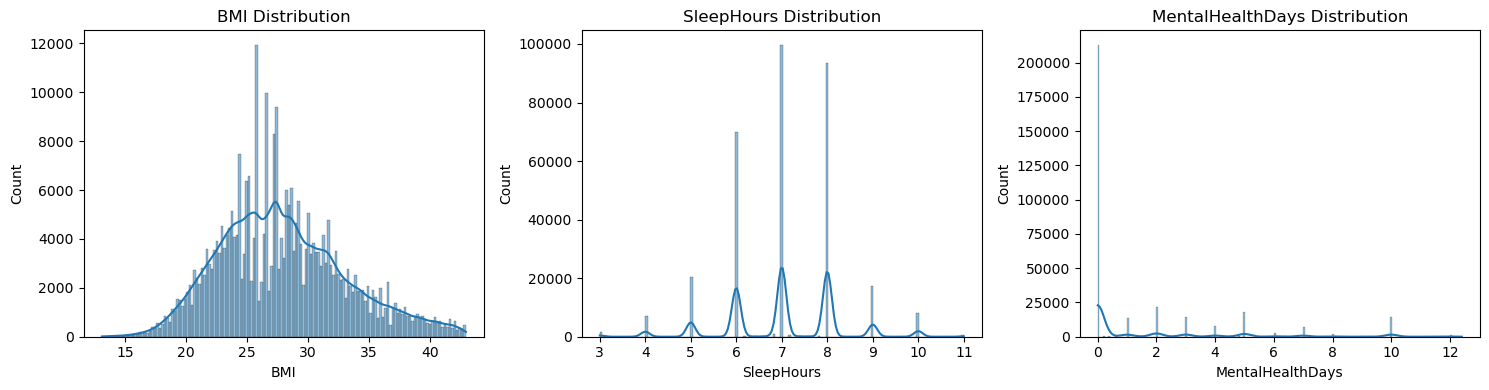

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(heart_cleaned['BMI'], kde=True, ax=axes[0])
axes[0].set_title("BMI Distribution")

sns.histplot(heart_cleaned['SleepHours'], kde=True, ax=axes[1])
axes[1].set_title("SleepHours Distribution")

sns.histplot(heart_cleaned['MentalHealthDays'], kde=True, ax=axes[2])
axes[2].set_title("MentalHealthDays Distribution")

plt.tight_layout()
plt.show()

**Log Normalization**

In [61]:
import numpy as np
heart_cleaned['MentalHealthDays'] = np.log1p(heart_cleaned['MentalHealthDays'])

**Standardization**

In [62]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['BMI', 'SleepHours', 'MentalHealthDays']

scaler = StandardScaler()
heart_cleaned[numeric_cols] = scaler.fit_transform(heart_cleaned[numeric_cols])

print("Standardization complete (mean ≈ 0, std ≈ 1):\n")
display(heart_cleaned[numeric_cols].head())

Standardization complete (mean ≈ 0, std ≈ 1):



,BMI,SleepHours,MentalHealthDays
0,-0.123379,0.774176,-0.652123
1,-0.259070,-0.850938,-0.652123
2,-0.442538,-1.663495,1.084259
3,-0.884008,-0.038381,-0.652123
4,-1.176411,1.586733,-0.652123


### **(3) Splitting the Dataset**

Here, it is assumed that our **target** is *Heart Disease* and everything else is a feature

In [63]:
# Check balance before split
print(heart_cleaned['HeartDisease'].value_counts(normalize=True))

HeartDisease
0    0.876811
1    0.123189
Name: proportion, dtype: float64


In [64]:
from sklearn.model_selection import train_test_split

# Separating features (X) and target (y)
X = heart_cleaned.drop(columns='HeartDisease')
y = heart_cleaned['HeartDisease']

# Splitting into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm the split
print("Dataset split complete: \n")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\n y_train distribution:\n", y_train.value_counts(normalize=True))
print("\n y_test distribution:\n", y_test.value_counts(normalize=True))

Dataset split complete: 

X_train shape: (257081, 13)
X_test shape:  (64271, 13)

 y_train distribution:
 HeartDisease
0    0.876809
1    0.123191
Name: proportion, dtype: float64

 y_test distribution:
 HeartDisease
0    0.876818
1    0.123182
Name: proportion, dtype: float64


### **Save to CSV** (full, final, cleaned dataset)

In [65]:
heart_onehot_encoded.to_csv("heart_final.csv", index=False)
print("Saved final dataset to heart_final.csv")

Saved final dataset to heart_final.csv


### **Save to CSV** (cleaned, label-encoded dataset)

In [66]:
heart_label_encoded.to_csv("heart_final_label.csv", index=False)
print("Saved final dataset to heart_final_label.csv")

Saved final dataset to heart_final_label.csv


### **Summary of Preprocessing Steps**

| Step | Type | Description |
|------|------|-------------|
| 1 | **Data Cleaning** | Handled missing values (MAR-aware imputation), removed duplicates and outliers (IQR method) |
| 2 | **Data Integration** | Combined `HadHeartAttack`, `HadAngina`, and `HadStroke` to create a binary target: `HeartDisease` |
| 3 | **Data Reduction** | Selected 14 medically relevant features; removed unused or duplicate information |
| 4 | **Data Transformation** | Encoded categorical variables (Label & One-Hot), log-transformed skewed values (`MentalHealthDays`), and standardized numerical variables (`BMI`, `SleepHours`) |
| 5 | **Outlier Handling** | IQR method used to remove outliers in `BMI`, `SleepHours`, and `MentalHealthDays` |
| 6 | **Final Dataset Split** | Stratified train-test split (80/20), ensuring class balance |
| 7 | **Output Saved** | Final data saved to `heart_final.csv` for future ML use |